In [223]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from db_connection import db, Songs, SongAudioFeatures

# Import from CSV
Normally I would use the database, but I decided to use the CSV file for reproducibility.

In [224]:
df_csv = pd.read_csv("songs_export.csv", index_col="id_x")
df_csv.index = df_csv.index.astype(str)
df_csv.index.name = "song_id"

audio_col_map = {
    "acousticness": "acousticness",
    "danceability": "danceability",
    "energy": "energy",
    "instrumentalness": "instrumentalness",
    "key": "key",
    "liveness": "liveness",
    "loudness": "loudness",
    "mode": "mode",
    "speechiness": "speechiness",
    "tempo": "tempo",
    "time_signature": "time_signature",
    "valence": "valence",
    "num_samples": "num_samples",
    "duration": "duration",
    "duration_ms": "duration_ms_y",
    "end_of_fade_in": "end_of_fade_in",
    "start_of_fade_out": "start_of_fade_out",
    "tempo_confidence": "tempo_confidence",
    "time_signature_confidence": "time_signature_confidence",
    "key_confidence": "key_confidence",
    "mode_confidence": "mode_confidence",
}
df_audio = df_csv[list(audio_col_map.values())].rename(columns={v: k for k, v in audio_col_map.items()})
df_audio["song_duration_ms"] = df_csv["duration_ms_x"]
df_audio["popularity"] = df_csv["popularity"]
df_audio["explicit"] = df_csv["explicit"].apply(lambda x: int(x) if pd.notna(x) else None)

def parse_embedding(s):
    if pd.isna(s):
        return [np.nan] * 768
    cleaned = " ".join(s.strip("[] \n").split())
    return np.fromstring(cleaned, sep=" ").tolist()

lyrics_emb_columns = [f"lyrics_emb_{i}" for i in range(768)]
lyrics_parsed = df_csv["lyrics_embeddings"].apply(parse_embedding)
df_lyrics_emb = pd.DataFrame(lyrics_parsed.tolist(), index=df_csv.index, columns=lyrics_emb_columns)
df_lyrics_emb.index.name = "song_id"

image_emb_columns = [f"image_emb_{i}" for i in range(768)]
image_parsed = df_csv["image_embeddings"].apply(parse_embedding)
df_image_emb = pd.DataFrame(image_parsed.tolist(), index=df_csv.index, columns=image_emb_columns)
df_image_emb.index.name = "song_id"

print(f"df_audio: {df_audio.shape}")
print(f"df_lyrics_emb: {df_lyrics_emb.shape}")
print(f"df_image_emb: {df_image_emb.shape}")

df_audio: (100, 24)
df_lyrics_emb: (100, 768)
df_image_emb: (100, 768)


In [225]:
df_audio.to_csv("songs_export_audio_features.csv")
df_lyrics_emb.to_csv("songs_export_lyrics_embeddings.csv")
df_image_emb.to_csv("songs_export_image_embeddings.csv")

# Euclidean Distance & Normalization
I normalize the data since not all features are on the same scale. Then I computed the euclidean distance between each song.

In [226]:
def euclidean_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:
    filled = df.fillna(df.median())
    dist_vec = pdist(filled.values, metric="euclidean")
    dist_mat = squareform(dist_vec)
    np.fill_diagonal(dist_mat, np.nan)
    return pd.DataFrame(dist_mat, index=df.index, columns=df.index)
def normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(axis=1, how="all")
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

df_audio_norm = normalize_df(df_audio)
df_lyrics_norm = normalize_df(df_lyrics_emb)
df_image_norm = normalize_df(df_image_emb)
dist_audio = euclidean_distance_matrix(df_audio_norm)
dist_lyrics = euclidean_distance_matrix(df_lyrics_norm)
dist_image = euclidean_distance_matrix(df_image_norm)

In [227]:
for label, raw, normed, dist in [
        ("Audio Features", df_audio, df_audio_norm, dist_audio),
        ("Lyrics Embeddings", df_lyrics_emb, df_lyrics_norm, dist_lyrics),
        ("Image Embeddings", df_image_emb, df_image_norm, dist_image),
    ]:
    print(f"{label}:")
    print(f"  Raw shape:        {raw.shape}")
    print(f"  Normalized range: {normed.min().min():.4f} to {normed.max().max():.4f}")
    print(f"  Distance matrix:  {dist.shape}")
    print(f"  Mean distance:    {dist.values[np.triu_indices_from(dist.values, k=1)].mean():.4f}")
    print()

Audio Features:
  Raw shape:        (100, 24)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    1.7597

Lyrics Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    5.4999

Image Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    8.5255



# K Means Clustering
I'm using K means clustering to group songs based on their features because it's simple and the same methods used in the example. Normally I would use a better method like hierarchical clustering or DBSCAN in a production environment.

In [228]:
def kmeans_cluster(df: pd.DataFrame, n_clusters: int, random_state: int = 42) -> pd.Series:
    filled = df.fillna(df.median())
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(filled.values)
    return pd.Series(labels, index=df.index, name="cluster"), km

# N Clusters
You might be wondering why I chose 2 clusters. I decided through trial and error that this was a good number of clusters to use. Typically I would use a silhouette score to determine the optimal number of clusters, but since we haven't covered that in class yet, I went with 2.

In [229]:
clusters = 2

audio_clusters, audio_km = kmeans_cluster(df_audio_norm, n_clusters=clusters)
lyrics_clusters, lyrics_km = kmeans_cluster(df_lyrics_norm, n_clusters=clusters)
image_clusters, image_km = kmeans_cluster(df_image_norm, n_clusters=clusters)

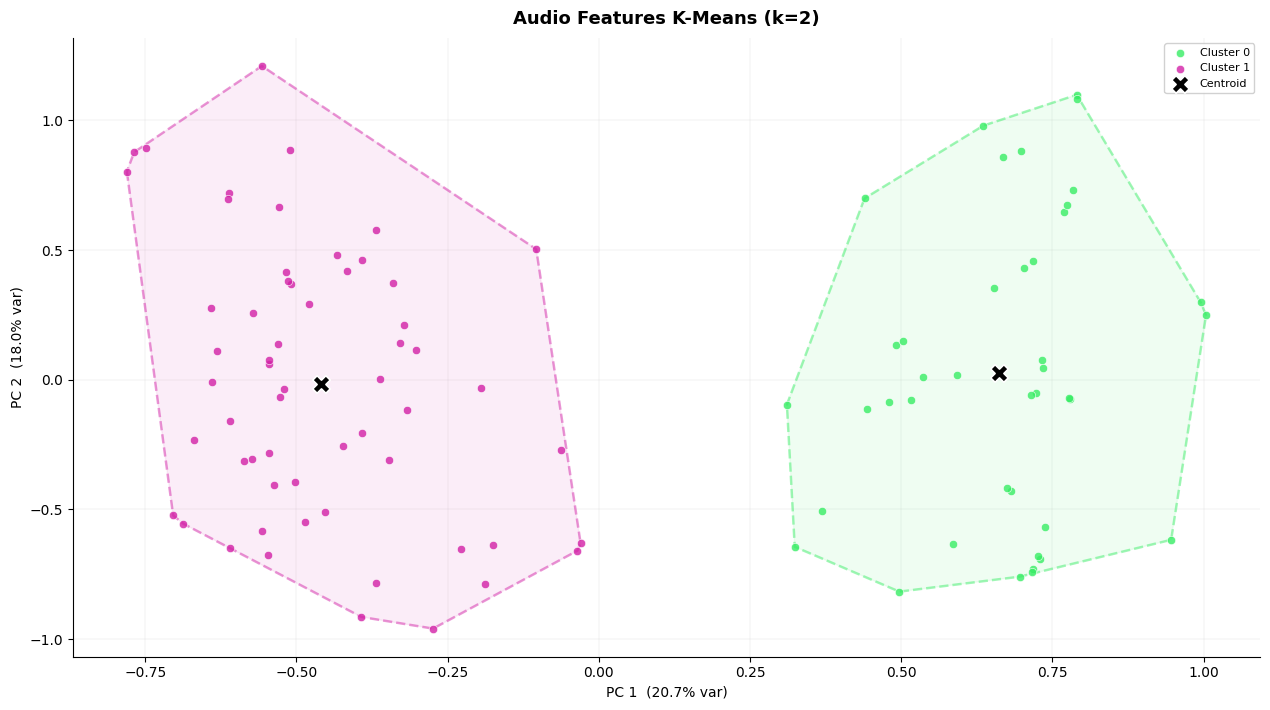

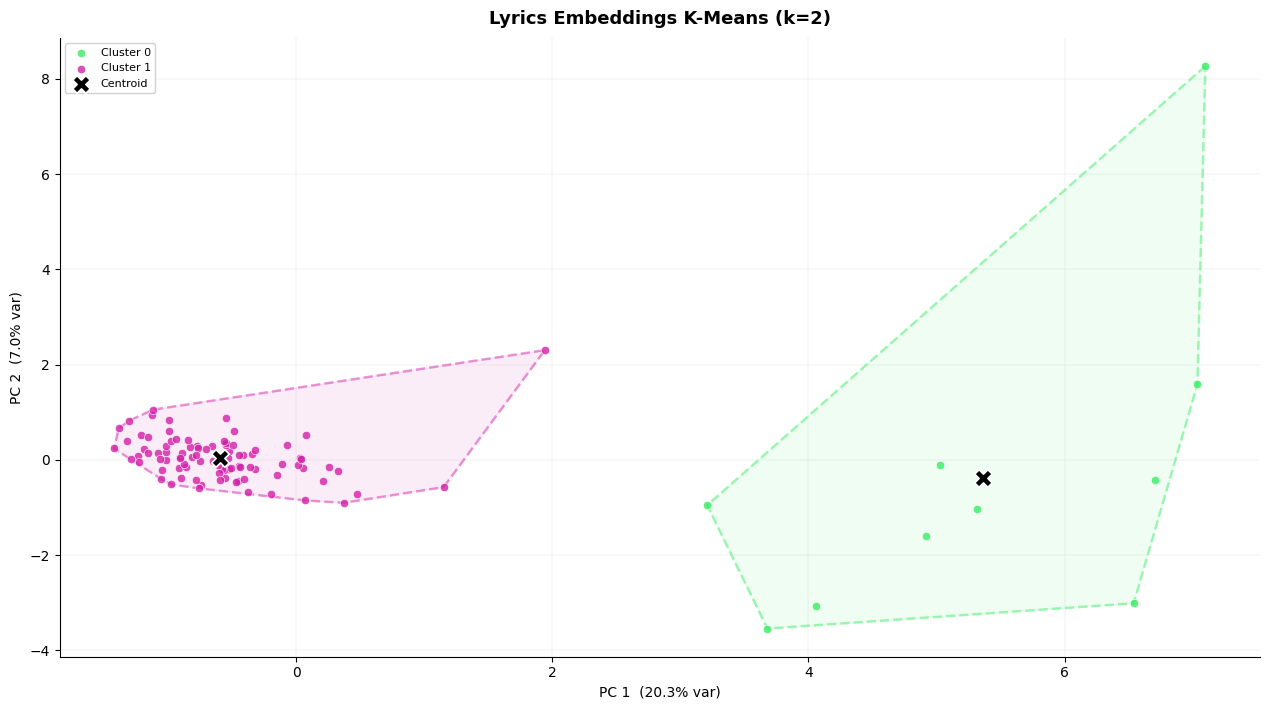

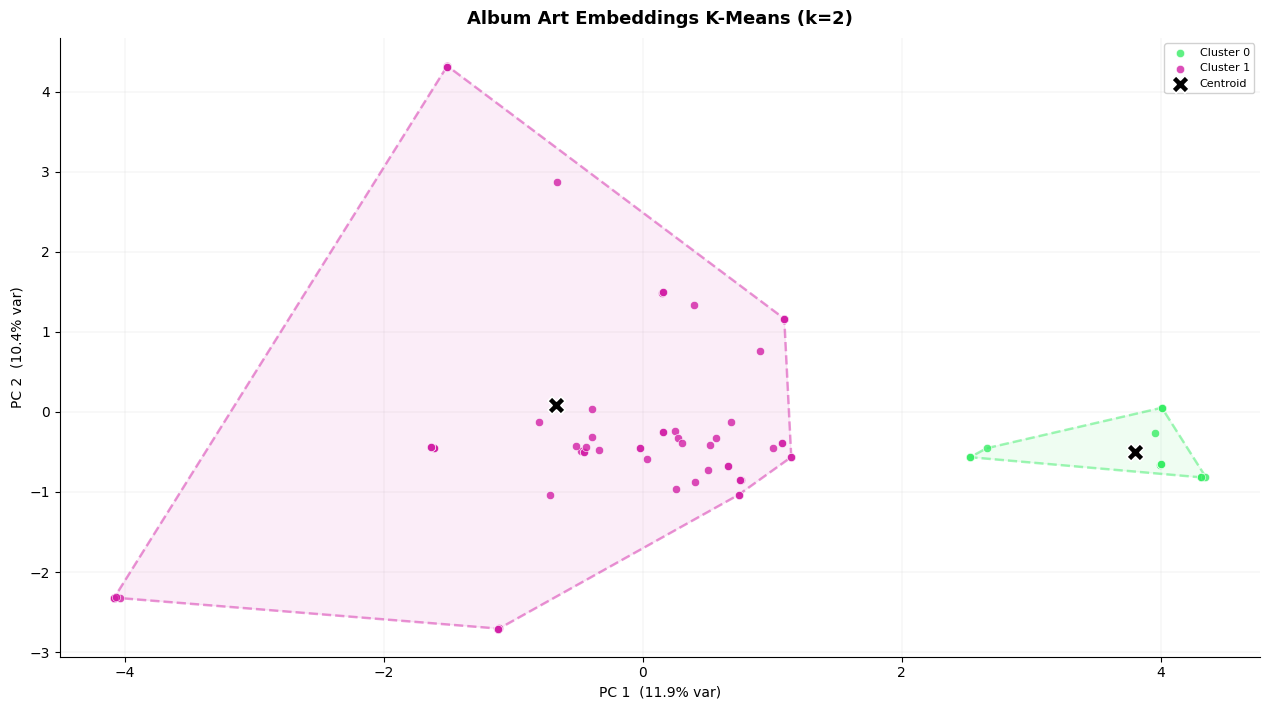

In [230]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

for df_norm, clust, km, title, fname in [
    (df_audio_norm,  audio_clusters,  audio_km,  "Audio Features K-Means (k={})".format(clusters),  "cluster_audio.png"),
    (df_lyrics_norm, lyrics_clusters, lyrics_km, "Lyrics Embeddings K-Means (k={})".format(clusters), "cluster_lyrics.png"),
    (df_image_norm,  image_clusters,  image_km,  "Album Art Embeddings K-Means (k={})".format(clusters), "cluster_image.png"),
]:
    fig, ax = plt.subplots(figsize=(W, H))
    plot_clusters_2d(df_norm, clust, km, title, ax)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()

# Merging Features
Although its cool for us humans to see this data seprately, its much easier for the computer to process if we merge them into one dataset. However, there is one caviat. Not all data features are created equal, although the symantic meaning of the cover is important, the audio features are much more important for a playlist to flow well. 

In [231]:
matrices = [dist_audio, dist_lyrics, dist_image]
weights = [0.7, 0.6, 0.3]

weights = np.array(weights) / np.sum(weights)
scaled = []
for mat in matrices:
    vals = mat.values
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    if hi - lo > 0:
        scaled.append((vals - lo) / (hi - lo))
    else:
        scaled.append(np.zeros_like(vals))
merged_vals = sum(w * s for w, s in zip(weights, scaled))
np.fill_diagonal(merged_vals, np.nan)
dist_merged = pd.DataFrame(merged_vals, index=matrices[0].index, columns=matrices[0].columns)

weighted = [df * w for df, w in zip(matrices, weights)]
merged_features =  pd.concat(weighted, axis=1)

merged_clusters, merged_km = kmeans_cluster(merged_features, n_clusters=clusters)

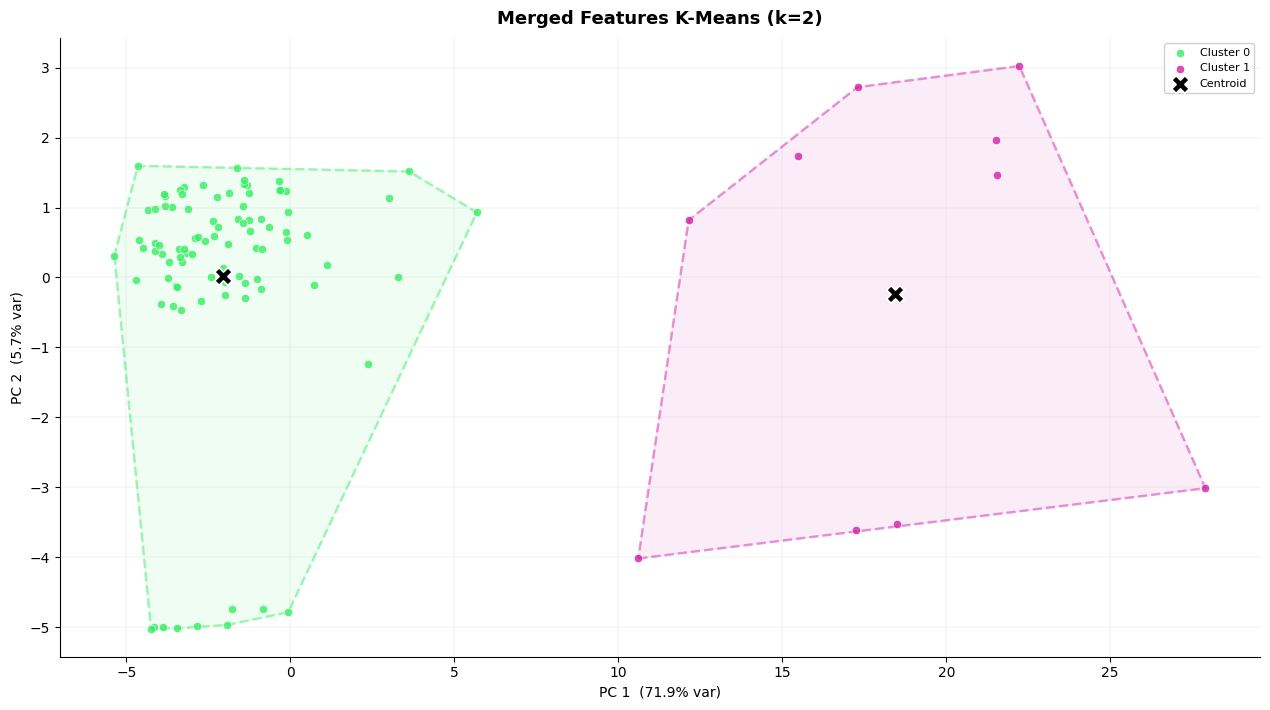

In [232]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

fig, ax = plt.subplots(figsize=(W, H))
plot_clusters_2d(merged_features, merged_clusters, merged_km, "Merged Features K-Means (k={})".format(clusters), ax)
fig.tight_layout()
fig.savefig("cluster_merged.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Flow Distance (Key + Tempo)
Like in Groupings.ipynb, we compute a separate **flow distance** that focuses on musical key and tempo — the two features that matter most for smooth DJ-style transitions. Key distance uses the **circle of fifths** (so C→G is closer than C→F#), and tempo distance is the normalized BPM difference. We blend flow distance with the merged distance so the playlist considers both harmonic flow and overall similarity.

In [233]:
# Circle of fifths: pitch class -> position on the circle
COF = {0:0, 7:1, 2:2, 9:3, 4:4, 11:5, 6:6, 1:7, 8:8, 3:9, 10:10, 5:11}

keys = df_audio["key"].fillna(0).astype(int).values
n = len(keys)

# Key distance: steps around the circle of fifths, normalized to [0, 1]
key_pos = np.array([COF.get(k, 0) for k in keys])
key_diff = np.abs(key_pos[:, None] - key_pos[None, :])
key_dist = np.minimum(key_diff, 12 - key_diff) / 6.0

# Tempo distance: normalized absolute BPM difference [0, 1]
tempos = df_audio_norm["tempo"].values
tempo_dist = np.abs(tempos[:, None] - tempos[None, :])

# Flow = 0.6 * key + 0.4 * tempo (same weights as Groupings.ipynb)
flow_vals = 0.6 * key_dist + 0.4 * tempo_dist
np.fill_diagonal(flow_vals, np.nan)
dist_flow = pd.DataFrame(flow_vals, index=df_audio.index, columns=df_audio.index)

# Blend: 0.5 * flow + 0.5 * merged for final playlist distance
# Scale merged to [0,1] first (flow is already [0,1])
m = dist_merged.values
m_lo, m_hi = np.nanmin(m), np.nanmax(m)
m_scaled = (m - m_lo) / (m_hi - m_lo)
blended = 0.5 * flow_vals + 0.5 * m_scaled
np.fill_diagonal(blended, np.nan)
dist_playlist = pd.DataFrame(blended, index=df_audio.index, columns=df_audio.index)

print(f"dist_flow  mean: {np.nanmean(dist_flow.values):.4f}")
print(f"dist_merged mean: {np.nanmean(dist_merged.values):.4f}")
print(f"dist_playlist (blended) mean: {np.nanmean(dist_playlist.values):.4f}")

dist_flow  mean: 0.3240
dist_merged mean: 0.5289
dist_playlist (blended) mean: 0.4595


# Smooth Transition Playlist

A smooth transition playlist picks songs so each one flows naturally into the next. The algorithm works like this:

1. **Compute a flow distance** from musical key (circle-of-fifths distance) and tempo (normalized BPM difference), weighted 0.6 key + 0.4 tempo — the same approach as Groupings.ipynb.
2. **Blend** the flow distance (50%) with the merged semantic distance (50%, from audio + lyrics + image) to get a final playlist distance that balances harmonic smoothness with overall similarity.
3. **Start** with a seed song S0 (the most "central" song — lowest average blended distance to all others).
4. **At each step**, find the **closest available song** by blended distance that:
   - Has **not already been selected**.
   - Has a **different primary artist** than the current song (hard constraint: no back-to-back repeats).
   - **Artist diversity penalty**: songs by artists already in the playlist have their distance increased by 0.15 per occurrence, encouraging broader artist representation.
5. **Variance injection** (every 2 steps): when the best flow distance is already smooth (< 0.25), blend 75% flow-closeness with 25% semantic distance to nudge toward different moods/artists.
6. **Tie-breaking:** If two songs are the exact same distance away, pick the one whose name comes first alphabetically.
7. **2-opt post-refinement**: After all 6 songs are selected, try reversing sub-segments of the ordering to reduce total distance (artist constraint still enforced on every swap).
8. **Repeat** until we have 6 songs: S0 → S1 → S2 → S3 → S4 → S5.

In [234]:
import ast

artist_series = df_csv["artists"].apply(lambda s: ast.literal_eval(s)[0])
song_name_series = df_csv["song_name"]

print(f"Songs: {len(artist_series)}")
print(f"Unique primary artists: {artist_series.nunique()}")
print(f"\nArtist distribution:")
print(artist_series.value_counts().to_string())

Songs: 100
Unique primary artists: 11

Artist distribution:
artists
Taylor Swift               25
Luke Bryan                 25
Beyoncé                    21
Ed Sheeran                 21
JAŸ-Z                       2
Nicki Minaj                 1
Macklemore & Ryan Lewis     1
Rudimental                  1
Stormzy                     1
Eminem                      1
Naughty Boy                 1


# Question 1
Below is a playlist of songs generated by using the computed distances to make a smooth transition between songs.

In [235]:
# === Smooth Transition Playlist (Improved) ===
# Improvements: artist diversity penalty, variance injection, 2-opt refinement

# --- Seed selection: most central song ---
avg_dist = dist_playlist.mean(axis=1)
start_song = avg_dist.idxmin()
print(f"Starting song (most central): {song_name_series[start_song]} by {artist_series[start_song]}")
print(f"  avg distance: {avg_dist[start_song]:.4f}\n")

# --- Greedy selection with diversity penalty + variance injection ---
playlist = [start_song]
selected = {start_song}

artist_penalty_weight = 0.15   # penalty per existing occurrence of an artist
variance_every = 2             # inject variance every N steps
variance_strength = 0.25       # blend ratio for semantic distance
max_variance_flow = 0.25       # only inject when best flow < this

for step in range(1, 6):
    current = playlist[-1]
    current_artist = artist_series[current]
    distances = dist_playlist.loc[current].copy()

    # block already-selected songs
    for sid in selected:
        distances[sid] = np.inf

    # hard block: no back-to-back same artist
    for sid in artist_series[artist_series == current_artist].index:
        if sid not in selected:
            distances[sid] = np.inf

    # soft penalty: add cost for artists already in the playlist
    artist_counts = {}
    for sid in playlist:
        a = artist_series[sid]
        artist_counts[a] = artist_counts.get(a, 0) + 1
    for sid in distances.index:
        if distances[sid] < np.inf:
            a = artist_series[sid]
            if a in artist_counts:
                distances[sid] += artist_penalty_weight * artist_counts[a]

    # fallback: if all blocked, relax to just "not selected"
    if distances.min() == np.inf:
        print(f"  WARNING step {step}: relaxing artist constraint")
        distances = dist_playlist.loc[current].copy()
        for sid in selected:
            distances[sid] = np.inf

    # variance injection: every N steps, blend semantic distance for diversity
    if step % variance_every == 0 and distances.min() < max_variance_flow:
        candidates = distances[distances < np.inf].index.tolist()
        if len(candidates) > 1:
            flow_vals_step = distances[candidates].values
            f_min, f_max = flow_vals_step.min(), flow_vals_step.max()
            flow_norm = (flow_vals_step - f_min) / (f_max - f_min) if f_max > f_min else np.zeros(len(candidates))
            flow_closeness = 1.0 - flow_norm

            sem_vals = dist_merged.loc[current, candidates].values
            s_min, s_max = sem_vals.min(), sem_vals.max()
            sem_norm = (sem_vals - s_min) / (s_max - s_min) if s_max > s_min else np.zeros(len(candidates))

            # higher semantic distance = more diverse
            score = (1 - variance_strength) * flow_closeness + variance_strength * sem_norm
            next_song = candidates[np.argmax(score)]
            print(f"  Step {step}: variance injection activated")
        else:
            min_dist = distances.min()
            tied = distances[distances == min_dist].index.tolist()
            tied.sort(key=lambda s: song_name_series[s].lower())
            next_song = tied[0]
    else:
        # standard greedy: closest, tie-break alphabetically
        min_dist = distances.min()
        tied = distances[distances == min_dist].index.tolist()
        tied.sort(key=lambda s: song_name_series[s].lower())
        next_song = tied[0]

    playlist.append(next_song)
    selected.add(next_song)

print(f"After greedy selection:")
for i, sid in enumerate(playlist):
    print(f"  S{i}: {artist_series[sid]} – {song_name_series[sid]}")

# --- 2-opt post-refinement ---
route = list(playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True
playlist = route

if iters > 1:
    print(f"\n2-opt refined in {iters} iterations")

# --- Print final playlist ---
print(f"\nSmooth Transition Playlist ({len(playlist)} songs):")
for i, sid in enumerate(playlist):
    if i == 0:
        print(f"  S{i}: {artist_series[sid]} – {song_name_series[sid]}  (start)")
    else:
        d = dist_playlist.loc[playlist[i-1], sid]
        print(f"  S{i}: {artist_series[sid]} – {song_name_series[sid]}  (dist from S{i-1}: {d:.4f})")

Starting song (most central): King Of My Heart by Taylor Swift
  avg distance: 0.3804

  Step 2: variance injection activated
  Step 4: variance injection activated
After greedy selection:
  S0: Taylor Swift – King Of My Heart
  S1: Ed Sheeran – Happier
  S2: Luke Bryan – Roller Coaster
  S3: Macklemore & Ryan Lewis – Growing Up (feat. Ed Sheeran)
  S4: Beyoncé – Before I Let Go - Homecoming Live Bonus Track
  S5: Eminem – River (feat. Ed Sheeran)

Smooth Transition Playlist (6 songs):
  S0: Taylor Swift – King Of My Heart  (start)
  S1: Ed Sheeran – Happier  (dist from S0: 0.1535)
  S2: Luke Bryan – Roller Coaster  (dist from S1: 0.2228)
  S3: Macklemore & Ryan Lewis – Growing Up (feat. Ed Sheeran)  (dist from S2: 0.2298)
  S4: Beyoncé – Before I Let Go - Homecoming Live Bonus Track  (dist from S3: 0.2215)
  S5: Eminem – River (feat. Ed Sheeran)  (dist from S4: 0.1785)


In [236]:
# Show playlist with all audio features and per-modality distances
features = df_audio_norm.columns.tolist()

rows = []
for i, sid in enumerate(playlist):
    row = {"Pos": f"S{i}", "Artist": artist_series[sid], "Song": song_name_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "--"
        row["Audio Dist"] = "--"
        row["Lyrics Dist"] = "--"
        row["Image Dist"] = "--"
        row["Merged Dist"] = "--"
        row["Blended Dist"] = "--"
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

# --- Enhanced stats ---
consec = list(range(len(playlist) - 1))
flow_d = [dist_flow.loc[playlist[i], playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[playlist[i], playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in consec]
image_d = [dist_image.loc[playlist[i], playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[playlist[i], playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in consec]

# pairwise semantic spread (all pairs, not just consecutive)
from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in playlist))

print(f"\n--- Smooth Transition Stats ---")
print(f"Mean consecutive distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (std: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (std: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (std: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (std: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (std: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (std: {np.std(blended_d):.4f})")
print(f"Semantic spread (avg pairwise merged dist): {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique — {', '.join(unique_artists)}")

Pos                  Artist                                          Song acousticness danceability energy instrumentalness   key liveness loudness  mode speechiness tempo time_signature valence num_samples duration end_of_fade_in start_of_fade_out tempo_confidence time_signature_confidence key_confidence mode_confidence song_duration_ms popularity explicit Flow Dist Audio Dist Lyrics Dist Image Dist Merged Dist Blended Dist
 S0            Taylor Swift                              King Of My Heart        0.427        0.709  0.871            0.518 0.900    0.752    0.737 0.000       0.716 0.315          0.750   0.466       0.231    0.231          0.026             0.238            0.546                     0.108          0.588           0.562            0.265      0.673    0.000        --         --          --         --          --           --
 S1              Ed Sheeran                                       Happier        0.389        0.732  0.950            0.580 0.900    0.632    

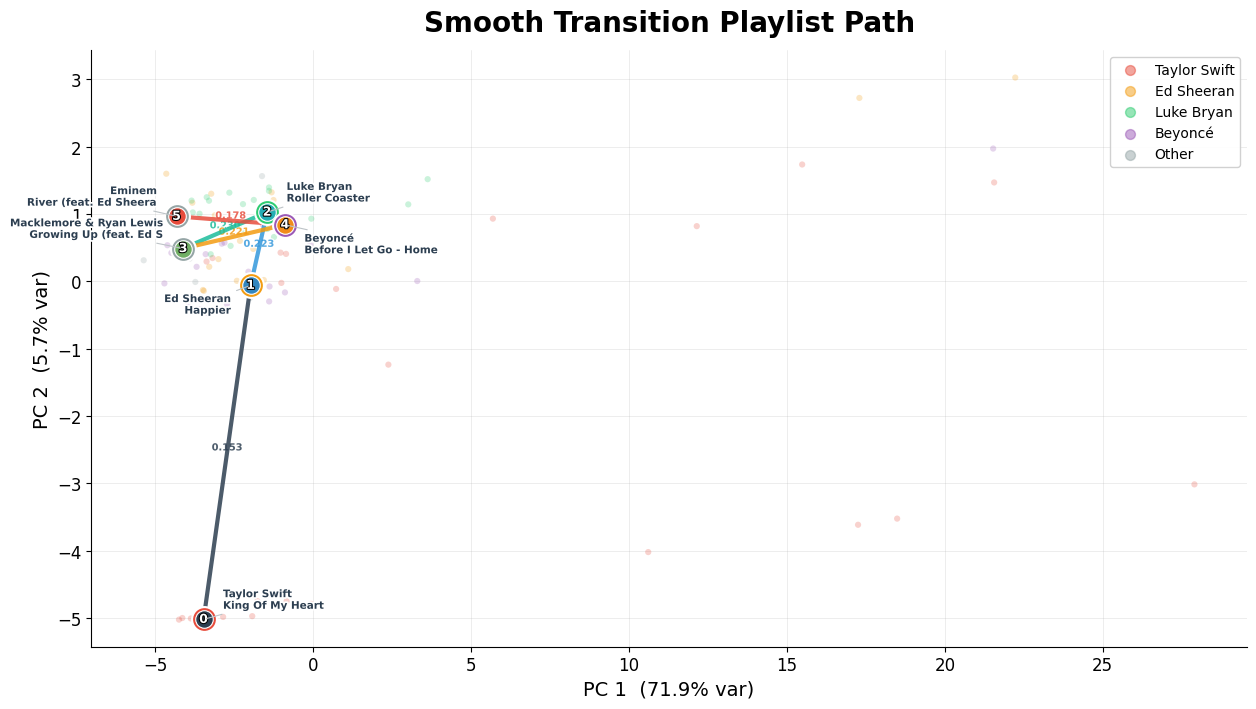

In [237]:
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

# 1920x1080 at 150 DPI
W, H, DPI = 1920 / 150, 1080 / 150, 150

# PCA to 2D
pca = PCA(n_components=2)
coords = pd.DataFrame(
    pca.fit_transform(merged_features.fillna(merged_features.median())),
    index=merged_features.index, columns=["PC1", "PC2"]
)

fig, ax = plt.subplots(figsize=(W, H))

# Background songs colored by artist
artist_colors = {
    "Taylor Swift": "#e74c3c", "Ed Sheeran": "#f39c12",
    "Luke Bryan": "#2ecc71", "Beyoncé": "#9b59b6",
}
default_color = "#95a5a6"

for sid in coords.index:
    a = artist_series[sid]
    c = artist_colors.get(a, default_color)
    is_in_playlist = sid in playlist
    ax.scatter(coords.loc[sid, "PC1"], coords.loc[sid, "PC2"],
               c=c, s=20 if not is_in_playlist else 0,
               alpha=0.25, edgecolors="none", zorder=1)

# Artist legend entries (background dots)
for artist, color in artist_colors.items():
    ax.scatter([], [], c=color, s=50, alpha=0.5, label=artist)
ax.scatter([], [], c=default_color, s=50, alpha=0.5, label="Other")

# Gradient path: color transitions from cool to warm along the playlist
path_cmap = LinearSegmentedColormap.from_list("path", ["#2c3e50", "#3498db", "#1abc9c", "#f39c12", "#e74c3c"])
pc = coords.loc[playlist]
n_songs = len(playlist)

for i in range(n_songs - 1):
    x = [pc["PC1"].iloc[i], pc["PC1"].iloc[i+1]]
    y = [pc["PC2"].iloc[i], pc["PC2"].iloc[i+1]]
    color = path_cmap(i / max(n_songs - 2, 1))
    d = dist_playlist.loc[playlist[i], playlist[i+1]]
    ax.plot(x, y, '-', color=color, linewidth=3, alpha=0.85, zorder=4)
    # distance label on each edge
    mx, my = np.mean(x), np.mean(y)
    ax.annotate(f"{d:.3f}", (mx, my), fontsize=7, color=color, alpha=0.8,
                fontweight="bold", ha="center", va="bottom",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# Playlist nodes: big markers with step numbers inside
for i, sid in enumerate(playlist):
    x, y = coords.loc[sid, "PC1"], coords.loc[sid, "PC2"]
    color = path_cmap(i / max(n_songs - 1, 1))
    a = artist_series[sid]
    ring_color = artist_colors.get(a, default_color)

    # outer ring (artist color)
    ax.scatter(x, y, s=320, c=ring_color, edgecolors="white", linewidths=1.5, zorder=6)
    # inner circle (path gradient)
    ax.scatter(x, y, s=160, c=[color], edgecolors="white", linewidths=0.8, zorder=7)
    # step number
    ax.text(x, y, str(i), ha="center", va="center", fontsize=9,
            fontweight="bold", color="white", zorder=8,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])

    # song label
    name = song_name_series[sid][:22]
    artist = artist_series[sid]
    label = f"{artist}\n{name}"
    # offset labels alternating sides to reduce overlap
    offset_x = 14 if i % 2 == 0 else -14
    offset_y = 14 if i % 3 != 1 else -14
    ha = "left" if offset_x > 0 else "right"
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(offset_x, offset_y), fontsize=7.5, ha=ha, va="center",
                fontweight="bold", color="#2c3e50",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
                arrowprops=dict(arrowstyle="-", color="#bdc3c7", lw=0.8),
                zorder=9)

ax.set_xlabel(f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=14)
ax.set_ylabel(f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=14)
ax.set_title("Smooth Transition Playlist Path", fontsize=20, fontweight="bold", pad=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9, edgecolor="#cccccc", fancybox=True)
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("smooth_playlist_path.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Thematic Structure Playlist

Instead of greedily chasing the nearest song, a thematic playlist uses **clustering** to divide the song pool into groups of similar songs, then picks **one representative from each cluster**.

1. **Cluster** the 100 songs into k=6 groups using K-means on the same merged features (audio, lyrics, image).
2. **Why k=6?** We need exactly 6 songs for the playlist. Using 6 clusters means each cluster contributes one song, guaranteeing the playlist spans every thematic region of the dataset — maximum diversity by design.
3. **Cross-cluster aware selection:** From each cluster, score every song by a blend of **centroid closeness** (60%, how representative it is) and **bridge quality** (40%, how close it is to other clusters' centroids). This picks songs that are both typical AND good transition points.
4. **Ordering:** The 6 representatives are ordered using greedy nearest-neighbor on blended distance with artist constraint.
5. **2-opt post-refinement:** Try reversing sub-segments of the ordering to reduce total distance (artist constraint enforced on every swap).
6. **Forward vs reversed:** Compare the ordering with its reverse; keep whichever has lower total distance.

In [238]:
# K-means with k=6 on merged features
thematic_k = 6
thematic_clusters, thematic_km = kmeans_cluster(merged_features, n_clusters=thematic_k)

print(f"Cluster sizes (k={thematic_k}):")
for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index
    artists_in = artist_series[members].value_counts()
    print(f"  Cluster {cid}: {len(members)} songs  —  {dict(artists_in)}")

Cluster sizes (k=6):
  Cluster 0: 32 songs  —  {'Luke Bryan': np.int64(15), 'Taylor Swift': np.int64(6), 'Ed Sheeran': np.int64(6), 'Beyoncé': np.int64(3), 'Rudimental': np.int64(1), 'Naughty Boy': np.int64(1)}
  Cluster 1: 6 songs  —  {'Taylor Swift': np.int64(3), 'Ed Sheeran': np.int64(2), 'Beyoncé': np.int64(1)}
  Cluster 2: 9 songs  —  {'Taylor Swift': np.int64(9)}
  Cluster 3: 4 songs  —  {'Taylor Swift': np.int64(4)}
  Cluster 4: 40 songs  —  {'Ed Sheeran': np.int64(13), 'Luke Bryan': np.int64(10), 'Beyoncé': np.int64(9), 'Taylor Swift': np.int64(3), 'Nicki Minaj': np.int64(1), 'Macklemore & Ryan Lewis': np.int64(1), 'Stormzy': np.int64(1), 'Eminem': np.int64(1), 'JAŸ-Z': np.int64(1)}
  Cluster 5: 9 songs  —  {'Beyoncé': np.int64(8), 'JAŸ-Z': np.int64(1)}


In [239]:
# === Thematic Structure Playlist (Improved) ===
# Improvements: cross-cluster aware selection, 2-opt, forward vs reversed

# --- Cross-cluster aware representative selection ---
filled = merged_features.fillna(merged_features.median())
centroids = thematic_km.cluster_centers_

representatives = []

for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index.tolist()

    # score each member: centroid closeness + cross-cluster bridge quality
    scores = []
    for sid in members:
        d_own = np.linalg.norm(filled.loc[sid].values - centroids[cid])
        d_others = [np.linalg.norm(filled.loc[sid].values - centroids[c]) for c in range(thematic_k) if c != cid]
        d_bridge = np.mean(d_others)
        scores.append((sid, d_own, d_bridge))

    # normalize both to [0,1] within cluster
    own_vals = np.array([s[1] for s in scores])
    bridge_vals = np.array([s[2] for s in scores])
    own_norm = (own_vals - own_vals.min()) / (own_vals.max() - own_vals.min()) if own_vals.max() > own_vals.min() else np.zeros(len(scores))
    bridge_norm = (bridge_vals - bridge_vals.min()) / (bridge_vals.max() - bridge_vals.min()) if bridge_vals.max() > bridge_vals.min() else np.zeros(len(scores))

    # 60% representativeness + 40% bridge quality (lower = better)
    combined = 0.6 * own_norm + 0.4 * bridge_norm
    best_idx = np.argmin(combined)
    best_sid = scores[best_idx][0]

    representatives.append(best_sid)
    print(f"Cluster {cid}: {song_name_series[best_sid]} by {artist_series[best_sid]}"
          f"  (centroid: {scores[best_idx][1]:.4f}, bridge: {scores[best_idx][2]:.4f})")

print(f"\nRepresentatives: {len(representatives)} songs")

# --- Greedy ordering ---
avg_d = dist_playlist.loc[representatives, representatives].mean(axis=1)
current = avg_d.idxmin()
thematic_playlist = [current]
remaining = set(representatives) - {current}

for step in range(1, 6):
    current = thematic_playlist[-1]
    current_artist = artist_series[current]

    diff_artist = [s for s in remaining if artist_series[s] != current_artist]
    pool = diff_artist if diff_artist else list(remaining)
    distances = dist_playlist.loc[current, pool].copy()

    min_dist = distances.min()
    tied = distances[distances == min_dist].index.tolist()
    tied.sort(key=lambda s: song_name_series[s].lower())
    next_song = tied[0]

    thematic_playlist.append(next_song)
    remaining.remove(next_song)

# --- 2-opt post-refinement ---
route = list(thematic_playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True
thematic_playlist = route

if iters > 1:
    print(f"2-opt refined in {iters} iterations")

# --- Forward vs reversed ---
fwd_cost = sum(dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in range(len(thematic_playlist)-1))
rev = list(reversed(thematic_playlist))
rev_ok = all(artist_series[rev[k]] != artist_series[rev[k+1]] for k in range(len(rev)-1))
if rev_ok:
    rev_cost = sum(dist_playlist.loc[rev[i], rev[i+1]] for i in range(len(rev)-1))
    if rev_cost < fwd_cost:
        thematic_playlist = rev
        print(f"Reversed ordering chosen (cost {rev_cost:.4f} < {fwd_cost:.4f})")
    else:
        print(f"Forward ordering kept (cost {fwd_cost:.4f} <= {rev_cost:.4f})")
else:
    print(f"Forward ordering kept (reversed violates artist constraint)")

# --- Print final playlist ---
print(f"\nThematic Playlist ({len(thematic_playlist)} songs):")
for i, sid in enumerate(thematic_playlist):
    cid = thematic_clusters[sid]
    if i == 0:
        print(f"  S{i}: [Cluster {cid}] {artist_series[sid]} – {song_name_series[sid]}  (start)")
    else:
        d = dist_playlist.loc[thematic_playlist[i-1], sid]
        print(f"  S{i}: [Cluster {cid}] {artist_series[sid]} – {song_name_series[sid]}  (dist: {d:.4f})")

Cluster 0: Sunrise, Sunburn, Sunset by Luke Bryan  (centroid: 2.5649, bridge: 10.5004)
Cluster 1: Delicate by Taylor Swift  (centroid: 4.7079, bridge: 21.3503)
Cluster 2: Daylight by Taylor Swift  (centroid: 2.2640, bridge: 11.9300)
Cluster 3: Don’t Blame Me by Taylor Swift  (centroid: 4.1058, bridge: 14.3009)
Cluster 4: Been There, Done That by Luke Bryan  (centroid: 2.4719, bridge: 11.2513)
Cluster 5: Lift Off by JAŸ-Z  (centroid: 1.6073, bridge: 11.8186)

Representatives: 6 songs
Forward ordering kept (cost 2.3084 <= 2.3084)

Thematic Playlist (6 songs):
  S0: [Cluster 2] Taylor Swift – Daylight  (start)
  S1: [Cluster 4] Luke Bryan – Been There, Done That  (dist: 0.4595)
  S2: [Cluster 3] Taylor Swift – Don’t Blame Me  (dist: 0.4712)
  S3: [Cluster 0] Luke Bryan – Sunrise, Sunburn, Sunset  (dist: 0.5739)
  S4: [Cluster 5] JAŸ-Z – Lift Off  (dist: 0.3697)
  S5: [Cluster 1] Taylor Swift – Delicate  (dist: 0.4342)


In [240]:
# Show thematic playlist with features and all distances
features = df_audio_norm.columns.tolist()

rows = []
for i, sid in enumerate(thematic_playlist):
    row = {"Pos": f"S{i}", "Cluster": thematic_clusters[sid],
           "Artist": artist_series[sid], "Song": song_name_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = thematic_playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "--"
        row["Audio Dist"] = "--"
        row["Lyrics Dist"] = "--"
        row["Image Dist"] = "--"
        row["Merged Dist"] = "--"
        row["Blended Dist"] = "--"
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

# --- Enhanced stats ---
consec = list(range(len(thematic_playlist) - 1))
flow_d = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
image_d = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]

from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in thematic_playlist))

print(f"\n--- Thematic Structure Stats ---")
print(f"Mean consecutive distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (std: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (std: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (std: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (std: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (std: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (std: {np.std(blended_d):.4f})")
print(f"Semantic spread (avg pairwise merged dist): {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique — {', '.join(unique_artists)}")

Pos  Cluster       Artist                     Song acousticness danceability energy instrumentalness   key liveness loudness  mode speechiness tempo time_signature valence num_samples duration end_of_fade_in start_of_fade_out tempo_confidence time_signature_confidence key_confidence mode_confidence song_duration_ms popularity explicit Flow Dist Audio Dist Lyrics Dist Image Dist Merged Dist Blended Dist
 S0        2 Taylor Swift                 Daylight        0.931        0.528  0.119            0.773 0.000    1.000    0.167 1.000       0.433 0.360          0.500   0.372       0.592    0.592          0.030             0.509            0.622                     0.622          0.647           0.625            0.592      0.836    0.000        --         --          --         --          --           --
 S1        4   Luke Bryan    Been There, Done That        0.204        0.388  0.582            0.626 0.500    0.119    0.989 1.000       0.881 0.897          0.000   0.922       0.231    0

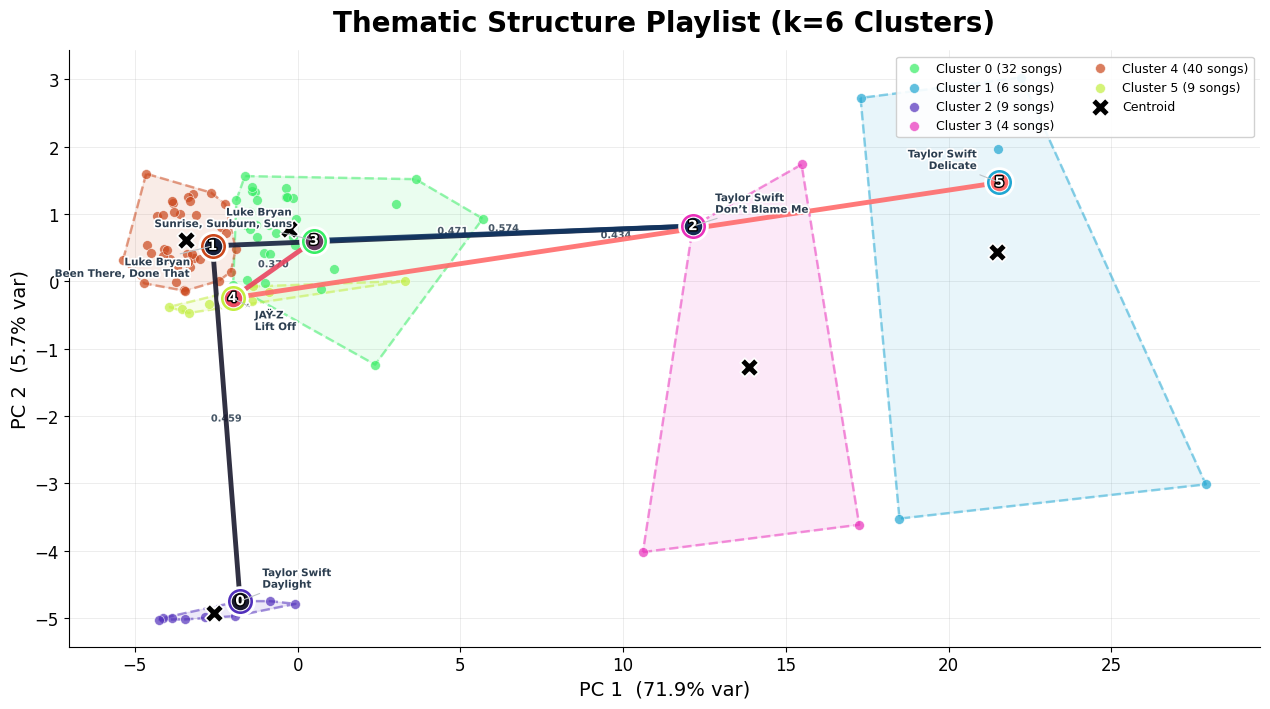

In [241]:
from sklearn.decomposition import PCA
from graphing_graphics import _generate_distinct_colors, _draw_cluster_hull
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

W, H, DPI = 1920 / 150, 1080 / 150, 150

# PCA to 2D
pca2 = PCA(n_components=2)
filled_vals = filled.values
coords2 = pd.DataFrame(
    pca2.fit_transform(filled_vals),
    index=merged_features.index, columns=["PC1", "PC2"]
)

fig, ax = plt.subplots(figsize=(W, H))

cluster_colors = _generate_distinct_colors(thematic_k, seed=42)

# Per-cluster: convex hull + scatter
for cid in range(thematic_k):
    mask = thematic_clusters == cid
    members = coords2[mask]
    pts = members.values
    c = cluster_colors[cid]

    _draw_cluster_hull(ax, pts, color=c, alpha_fill=0.10, alpha_edge=0.5)

    ax.scatter(members["PC1"], members["PC2"], c=c, s=50, alpha=0.70,
               edgecolors="white", linewidths=0.5, zorder=3,
               label=f"Cluster {cid} ({mask.sum()} songs)")

# Cluster centroids in 2D
centres_2d = pca2.transform(thematic_km.cluster_centers_)
ax.scatter(centres_2d[:, 0], centres_2d[:, 1], c="black", marker="X", s=180,
           edgecolors="white", linewidths=1.2, zorder=5, label="Centroid")

# Playlist path with gradient coloring
path_cmap = LinearSegmentedColormap.from_list("tpath", ["#1a1a2e", "#16213e", "#0f3460", "#e94560", "#ff6b6b"])
pc = coords2.loc[thematic_playlist]
n_songs = len(thematic_playlist)

for i in range(n_songs - 1):
    x = [pc["PC1"].iloc[i], pc["PC1"].iloc[i+1]]
    y = [pc["PC2"].iloc[i], pc["PC2"].iloc[i+1]]
    color = path_cmap(i / max(n_songs - 2, 1))
    d = dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]]
    ax.plot(x, y, '-', color=color, linewidth=3.5, alpha=0.9, zorder=6)
    # distance label on each edge
    mx, my = np.mean(x), np.mean(y)
    ax.annotate(f"{d:.3f}", (mx, my), fontsize=7, color="#2c3e50", alpha=0.85,
                fontweight="bold", ha="center", va="bottom",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

# Playlist nodes: numbered markers with cluster-colored rings
for i, sid in enumerate(thematic_playlist):
    x, y = coords2.loc[sid, "PC1"], coords2.loc[sid, "PC2"]
    cid = thematic_clusters[sid]
    ring_color = cluster_colors[cid]
    inner_color = path_cmap(i / max(n_songs - 1, 1))

    # outer ring (cluster color)
    ax.scatter(x, y, s=400, c=ring_color, edgecolors="white", linewidths=2, zorder=8)
    # inner circle (path gradient)
    ax.scatter(x, y, s=180, c=[inner_color], edgecolors="white", linewidths=0.8, zorder=9)
    # step number
    ax.text(x, y, str(i), ha="center", va="center", fontsize=10,
            fontweight="bold", color="white", zorder=10,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

    # song label
    name = song_name_series[sid][:22]
    artist = artist_series[sid]
    label = f"{artist}\n{name}"
    offset_x = 16 if i % 2 == 0 else -16
    offset_y = 16 if i % 3 != 1 else -16
    ha_align = "left" if offset_x > 0 else "right"
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(offset_x, offset_y), fontsize=7.5, ha=ha_align, va="center",
                fontweight="bold", color="#2c3e50",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
                arrowprops=dict(arrowstyle="-", color="#bdc3c7", lw=0.8),
                zorder=11)

ax.set_xlabel(f"PC 1  ({pca2.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=14)
ax.set_ylabel(f"PC 2  ({pca2.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=14)
ax.set_title("Thematic Structure Playlist (k=6 Clusters)", fontsize=20, fontweight="bold", pad=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=9, loc="upper right", framealpha=0.9, edgecolor="#cccccc",
          fancybox=True, ncol=2)
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("thematic_playlist_path.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Alice's Random Playlist

Alice ignores all features and distances. She picks 6 songs **uniformly at random**, with the only constraint being that **at least one song from each of the 4 major artists** (Taylor Swift, Luke Bryan, Beyoncé, Ed Sheeran) is included. The remaining 2 slots are filled randomly from the leftover pool. The playlist order is also random.

This serves as a baseline — we expect the smooth transition and thematic playlists to have noticeably lower transition distances than a random selection.

In [242]:
rng = np.random.default_rng(seed=42)

# Guarantee one song from each of the 4 major artists
major_artists = ["Taylor Swift", "Luke Bryan", "Beyoncé", "Ed Sheeran"]
alice_picks = []
for artist in major_artists:
    pool = artist_series[artist_series == artist].index.tolist()
    alice_picks.append(rng.choice(pool))

# Fill remaining 2 slots randomly from the rest
remaining_pool = [s for s in artist_series.index if s not in alice_picks]
extras = rng.choice(remaining_pool, size=2, replace=False)
alice_picks.extend(extras.tolist())

# Shuffle the order randomly
rng.shuffle(alice_picks)
alice_playlist = alice_picks

print(f"Alice's Random Playlist ({len(alice_playlist)} songs):")
for i, sid in enumerate(alice_playlist):
    name = song_name_series[sid]
    artist = artist_series[sid]
    if i == 0:
        print(f"  S{i}: {artist} – {name}  (start)")
    else:
        d = dist_playlist.loc[alice_playlist[i-1], sid]
        print(f"  S{i}: {artist} – {name}  (dist from S{i-1}: {d:.4f})")

Alice's Random Playlist (6 songs):
  S0: Taylor Swift – King Of My Heart  (start)
  S1: Beyoncé – Haunted  (dist from S0: 0.3226)
  S2: Ed Sheeran – Afire Love  (dist from S1: 0.6745)
  S3: Luke Bryan – Move  (dist from S2: 0.4472)
  S4: Taylor Swift – Cruel Summer  (dist from S3: 0.4711)
  S5: Ed Sheeran – Dive  (dist from S4: 0.2478)


In [243]:
# Show Alice's playlist with features and all distances
features = df_audio_norm.columns.tolist()

rows = []
for i, sid in enumerate(alice_playlist):
    row = {"Pos": f"S{i}", "Artist": artist_series[sid], "Song": song_name_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = alice_playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "--"
        row["Audio Dist"] = "--"
        row["Lyrics Dist"] = "--"
        row["Image Dist"] = "--"
        row["Merged Dist"] = "--"
        row["Blended Dist"] = "--"
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

# --- Enhanced stats for Alice ---
from itertools import combinations

consec = list(range(len(alice_playlist) - 1))
a_flow = [dist_flow.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_audio = [dist_audio.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_lyrics = [dist_lyrics.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_image = [dist_image.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_merged = [dist_merged.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_blended = [dist_playlist.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
a_pairs = [dist_merged.loc[a, b] for a, b in combinations(alice_playlist, 2)]
a_artists = list(set(artist_series[sid] for sid in alice_playlist))

print(f"\n--- Alice's Random Stats ---")
print(f"Mean consecutive distances:")
print(f"  Flow:    {np.mean(a_flow):.4f}  (std: {np.std(a_flow):.4f}, max: {max(a_flow):.4f})")
print(f"  Audio:   {np.mean(a_audio):.4f}  (std: {np.std(a_audio):.4f})")
print(f"  Lyrics:  {np.mean(a_lyrics):.4f}  (std: {np.std(a_lyrics):.4f})")
print(f"  Image:   {np.mean(a_image):.4f}  (std: {np.std(a_image):.4f})")
print(f"  Merged:  {np.mean(a_merged):.4f}  (std: {np.std(a_merged):.4f})")
print(f"  Blended: {np.mean(a_blended):.4f}  (std: {np.std(a_blended):.4f})")
print(f"Semantic spread (avg pairwise merged dist): {np.mean(a_pairs):.4f}")
print(f"Artist diversity: {len(a_artists)} unique — {', '.join(a_artists)}")

# === Full comparison table across all 3 playlists ===
print("\n" + "="*80)
print("PLAYLIST COMPARISON")
print("="*80)

# Recompute smooth transition stats
s_consec = list(range(len(playlist) - 1))
s_flow = [dist_flow.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_audio = [dist_audio.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_lyrics = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_image = [dist_image.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_merged = [dist_merged.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_blended = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_pairs = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]
s_artists = list(set(artist_series[sid] for sid in playlist))

# Recompute thematic stats
t_consec = list(range(len(thematic_playlist) - 1))
t_flow = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_audio = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_lyrics = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_image = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_merged = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_blended = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_pairs = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]
t_artists = list(set(artist_series[sid] for sid in thematic_playlist))

comparison = pd.DataFrame({
    "Metric": [
        "Mean Flow Dist", "Max Flow Dist", "Std Flow Dist",
        "Mean Audio Dist", "Mean Lyrics Dist", "Mean Image Dist",
        "Mean Merged Dist", "Mean Blended Dist",
        "Semantic Spread", "Unique Artists"
    ],
    "Smooth Transition": [
        f"{np.mean(s_flow):.4f}", f"{max(s_flow):.4f}", f"{np.std(s_flow):.4f}",
        f"{np.mean(s_audio):.4f}", f"{np.mean(s_lyrics):.4f}", f"{np.mean(s_image):.4f}",
        f"{np.mean(s_merged):.4f}", f"{np.mean(s_blended):.4f}",
        f"{np.mean(s_pairs):.4f}", f"{len(s_artists)}"
    ],
    "Thematic Structure": [
        f"{np.mean(t_flow):.4f}", f"{max(t_flow):.4f}", f"{np.std(t_flow):.4f}",
        f"{np.mean(t_audio):.4f}", f"{np.mean(t_lyrics):.4f}", f"{np.mean(t_image):.4f}",
        f"{np.mean(t_merged):.4f}", f"{np.mean(t_blended):.4f}",
        f"{np.mean(t_pairs):.4f}", f"{len(t_artists)}"
    ],
    "Alice's Random": [
        f"{np.mean(a_flow):.4f}", f"{max(a_flow):.4f}", f"{np.std(a_flow):.4f}",
        f"{np.mean(a_audio):.4f}", f"{np.mean(a_lyrics):.4f}", f"{np.mean(a_image):.4f}",
        f"{np.mean(a_merged):.4f}", f"{np.mean(a_blended):.4f}",
        f"{np.mean(a_pairs):.4f}", f"{len(a_artists)}"
    ]
})
print(comparison.to_string(index=False))

Pos       Artist             Song acousticness danceability energy instrumentalness   key liveness loudness  mode speechiness tempo time_signature valence num_samples duration end_of_fade_in start_of_fade_out tempo_confidence time_signature_confidence key_confidence mode_confidence song_duration_ms popularity explicit Flow Dist Audio Dist Lyrics Dist Image Dist Merged Dist Blended Dist
 S0 Taylor Swift King Of My Heart        0.427        0.709  0.871            0.518 0.900    0.752    0.737 0.000       0.716 0.315          0.750   0.466       0.231    0.231          0.026             0.238            0.546                     0.108          0.588           0.562            0.265      0.673    0.000        --         --          --         --          --           --
 S1      Beyoncé          Haunted        0.935        0.686  0.060            0.588 0.900    1.000    0.000 0.000       0.057 0.517          1.000   0.198       0.333    0.333          0.043             0.333            0.